# Car Price Prediction Using Machine Learning

## Objective
The objective of this project is to build a machine learning model
that predicts the selling price of used cars based on features such
as car age, kilometres driven, fuel type, seller type, transmission,
and ownership.

## Dataset
The dataset used in this project is the CarDekho used-car dataset
("Vehicle dataset from cardekho" on Kaggle), loaded from
`CAR DETAILS FROM CAR DEKHO.csv`.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
RANDOM_STATE = 42

In [2]:
df = pd.read_csv("CAR DETAILS FROM CAR DEKHO.csv")

df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


## 1. Understanding the Dataset

Before building the machine learning model, we first inspect the
dataset to understand its structure, columns, data types, and
overall size.

In [3]:
print("Number of rows and columns:", df.shape)

df.info()

print("\nDescriptive Statistics:")
df.describe()

Number of rows and columns: (4340, 8)
<class 'pandas.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   name           4340 non-null   str  
 1   year           4340 non-null   int64
 2   selling_price  4340 non-null   int64
 3   km_driven      4340 non-null   int64
 4   fuel           4340 non-null   str  
 5   seller_type    4340 non-null   str  
 6   transmission   4340 non-null   str  
 7   owner          4340 non-null   str  
dtypes: int64(3), str(5)
memory usage: 515.2 KB

Descriptive Statistics:


,year,selling_price,km_driven
count,4340.000000,4.340000e+03,4340.000000
mean,2013.090783,5.041273e+05,66215.777419
std,4.215344,5.785487e+05,46644.102194
min,1992.000000,2.000000e+04,1.000000
25%,2011.000000,2.087498e+05,35000.000000
50%,2014.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


## 2. Data Quality Check

We check for missing values and duplicate records, and standardise
categorical text values (e.g. inconsistent casing/whitespace such as
"Petrol" vs "petrol") before doing any analysis or model training.

In [4]:
print("Total missing values:", df.isnull().sum().sum())
print("Total duplicate rows:", df.duplicated().sum())

df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Total missing values: 0
Total duplicate rows: 763
Shape after removing duplicates: (3577, 8)


In [5]:
# Standardise categorical text: trim whitespace and use consistent
# title case, so values like "petrol" / "Petrol " / "PETROL" are
# always treated as the same category.
categorical_text_cols = ["name", "fuel", "seller_type", "transmission", "owner"]

for col in categorical_text_cols:
    df[col] = df[col].astype(str).str.strip().str.title()

print("Unique fuel types:", df["fuel"].unique())
print("Unique seller types:", df["seller_type"].unique())
print("Unique transmission types:", df["transmission"].unique())
print("Unique owner types:", df["owner"].unique())

Unique fuel types: <ArrowStringArray>
['Petrol', 'Diesel', 'Cng', 'Lpg', 'Electric']
Length: 5, dtype: str
Unique seller types: <ArrowStringArray>
['Individual', 'Dealer', 'Trustmark Dealer']
Length: 3, dtype: str
Unique transmission types: <ArrowStringArray>
['Manual', 'Automatic']
Length: 2, dtype: str
Unique owner types: <ArrowStringArray>
[         'First Owner',         'Second Owner', 'Fourth & Above Owner',
          'Third Owner',       'Test Drive Car']
Length: 5, dtype: str


## 3. Feature Engineering

Three engineered features are created:

1. **`car_age`** – calculated from the manufacturing year.
2. **`brand`** – extracted from the first word of the car name.
3. **`km_per_year`** – average kilometres driven per year of the
   car's life. This captures usage intensity better than raw
   `km_driven` alone (a 10-year-old car with 100,000 km has been
   driven much less per year than a 2-year-old car with the same
   mileage), and gives the models a genuinely new signal rather than
   a restatement of `car_age` and `km_driven`.

`brand` is used for modelling instead of the raw `name` column: the
raw car name has hundreds of near-unique values (e.g. "Maruti Wagon R
LXI Minor"), which one-hot encodes into an enormous, mostly-empty
feature space that mostly memorises individual rows rather than
generalising. `brand` (29 categories) keeps the useful "which
manufacturer" signal without that overfitting risk.

In [6]:
# The dataset's cars were listed around 2020, so this is used as the
# reference year for computing age.
CURRENT_YEAR = 2020

df["car_age"] = CURRENT_YEAR - df["year"]

# Extract brand from the car name (first word), e.g. "Maruti 800 AC" -> "Maruti"
df["brand"] = df["name"].str.split().str[0]

# Avoid division by zero for brand-new (age 0) cars
df["km_per_year"] = df["km_driven"] / df["car_age"].replace(0, 1)

df[["name", "year", "car_age", "brand", "km_driven", "km_per_year"]].head()

,name,year,car_age,brand,km_driven,km_per_year
0,Maruti 800 Ac,2007,13,Maruti,70000,5384.615385
1,Maruti Wagon R Lxi Minor,2007,13,Maruti,50000,3846.153846
2,Hyundai Verna 1.6 Sx,2012,8,Hyundai,100000,12500.000000
3,Datsun Redigo T Option,2017,3,Datsun,46000,15333.333333
4,Honda Amaze Vx I-Dtec,2014,6,Honda,141000,23500.000000


In [7]:
print("Number of unique brands:", df["brand"].nunique())
df["brand"].value_counts()

Number of unique brands: 29


brand
Maruti           1072
Hyundai           637
Mahindra          328
Tata              308
Ford              220
Honda             216
Toyota            170
Chevrolet         151
Renault           110
Volkswagen         93
Nissan             52
Skoda              49
Fiat               32
Audi               31
Datsun             29
Bmw                25
Mercedes-Benz      21
Jaguar              5
Mitsubishi          5
Land                5
Volvo               4
Jeep                3
Ambassador          3
Mg                  2
Opelcorsa           2
Daewoo              1
Force               1
Isuzu               1
Kia                 1
Name: count, dtype: int64

## 4. Handling Outliers

The dataset contains a very small number of extremely high-priced
cars (luxury vehicles) that are far outside the range the model can
reasonably learn to predict from limited examples. Left in, they
pull the loss function toward fitting a handful of rare, extreme
points at the expense of accuracy on the vast majority of
"ordinary" used cars. The top 0.5% of prices are capped by removing
those rows.

In [8]:
price_cap = df["selling_price"].quantile(0.995)
rows_before = df.shape[0]

df = df[df["selling_price"] <= price_cap]

print(f"Price cap (99.5th percentile): {price_cap:,.0f}")
print(f"Rows removed as extreme outliers: {rows_before - df.shape[0]}")
print("Shape after outlier removal:", df.shape)

Price cap (99.5th percentile): 3,285,280
Rows removed as extreme outliers: 18
Shape after outlier removal: (3559, 11)


## 5. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand the
distribution of selling prices and the relationship between
different car features and resale prices.

### Distribution of Selling Prices

The following histogram shows how the selling prices of used cars
are distributed in the dataset.

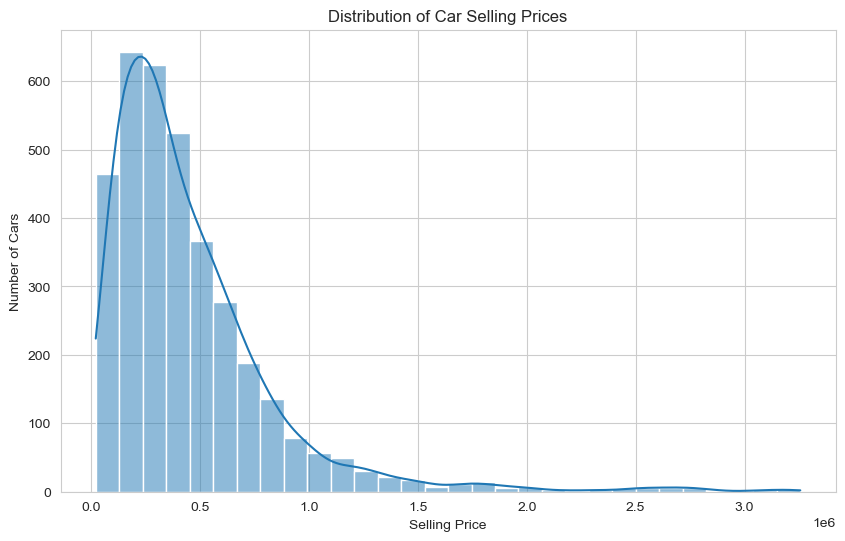

In [9]:
plt.figure(figsize=(10, 6))
sns.histplot(df["selling_price"], bins=30, kde=True)
plt.title("Distribution of Car Selling Prices")
plt.xlabel("Selling Price")
plt.ylabel("Number of Cars")
plt.show()

**Observation:** The selling price distribution is positively
skewed (right-skewed). Most used cars have relatively low selling
prices, while a smaller number of cars have much higher prices. This
is exactly the kind of distribution where training on `log(price)`
rather than raw price tends to help a regression model, since it
stops the largest prices from dominating the error metric during
training.

### Selling Price vs Fuel Type

A box plot is used to compare the distribution of selling prices
across different fuel types.

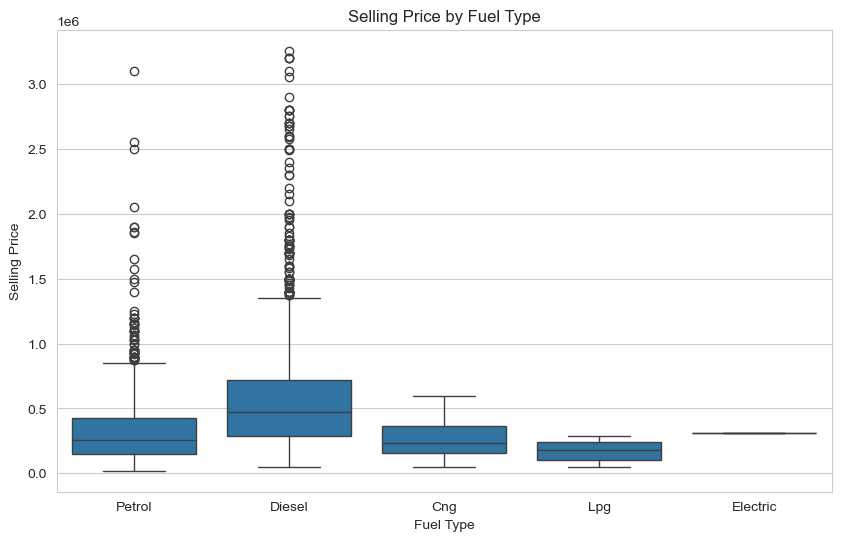

In [10]:
plt.figure(figsize=(10, 6))
sns.boxplot(x="fuel", y="selling_price", data=df)
plt.title("Selling Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Selling Price")
plt.show()

**Observation:** Diesel cars generally have higher selling prices
than the other fuel types. Petrol cars show a wide range of prices.
CNG and LPG cars tend to have lower selling prices.

### Selling Price vs Car Age

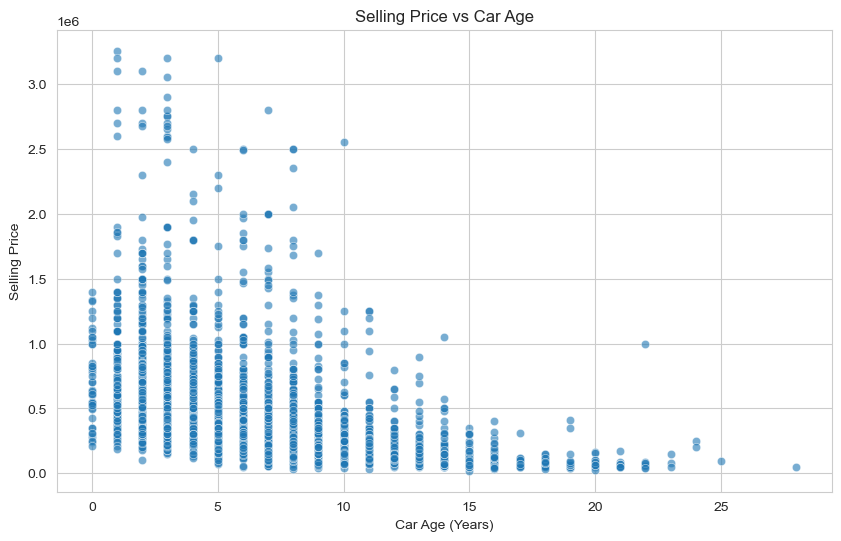

In [11]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x="car_age", y="selling_price", data=df, alpha=0.6)
plt.title("Selling Price vs Car Age")
plt.xlabel("Car Age (Years)")
plt.ylabel("Selling Price")
plt.show()

**Observation:** Newer cars tend to have higher resale prices,
while older cars generally have lower prices, consistent with
depreciation.

### Selling Price vs Kilometres Driven

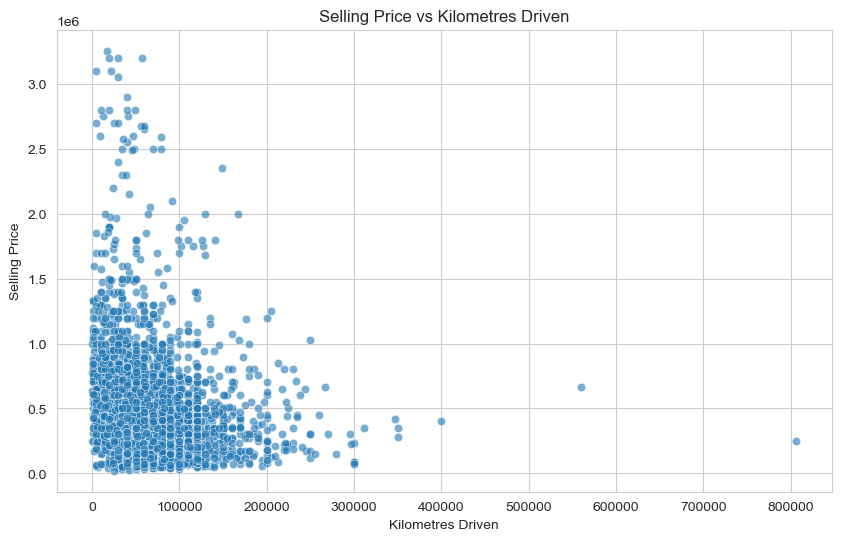

In [12]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x="km_driven", y="selling_price", data=df, alpha=0.6)
plt.title("Selling Price vs Kilometres Driven")
plt.xlabel("Kilometres Driven")
plt.ylabel("Selling Price")
plt.show()

**Observation:** Cars with higher kilometres driven tend to have
lower selling prices, though the relationship is noisy — other
factors such as brand, age, and fuel type also matter, which is why
a multi-feature model is needed rather than relying on this single
variable.

## 6. Feature Correlation Analysis

A correlation matrix measures the strength and direction of linear
relationships between numerical variables.

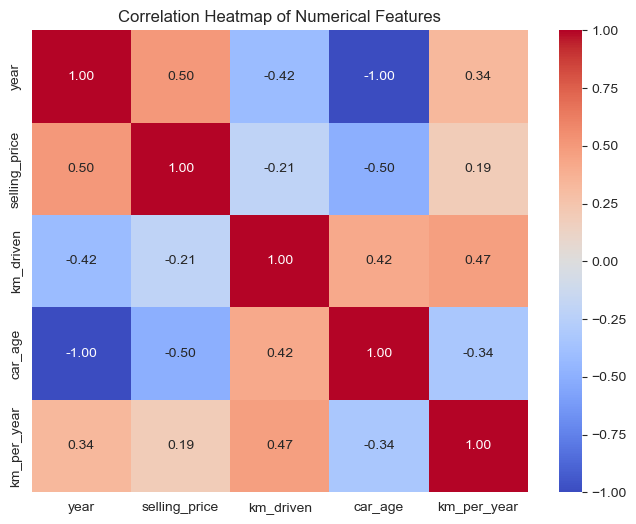

In [13]:
numeric_columns = ["year", "selling_price", "km_driven", "car_age", "km_per_year"]

correlation_matrix = df[numeric_columns].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

**Observation:** `year` and `car_age` are (as expected) perfectly
anti-correlated with each other, since one is derived from the
other. `car_age` has a moderate negative correlation with
`selling_price`, and `km_driven` a weaker negative correlation.
`km_per_year` adds a slightly different signal from either.

## 7. Preparing Data for Machine Learning

The target variable is `selling_price`. Because its distribution is
right-skewed (see Section 5), the models are trained on
`log1p(selling_price)` rather than the raw price. Predictions are
converted back to the original rupee scale with `expm1` before
computing MAE, RMSE, and R², so the reported metrics stay directly
interpretable as rupee amounts.

The input features are:
- `brand` (extracted from the car name)
- `car_age`
- `km_driven`
- `km_per_year`
- `fuel`
- `seller_type`
- `transmission`
- `owner`

In [14]:
feature_columns = [
    "brand",
    "car_age",
    "km_driven",
    "km_per_year",
    "fuel",
    "seller_type",
    "transmission",
    "owner",
]

X = df[feature_columns]
y_log = np.log1p(df["selling_price"])   # log-transformed target used for training

print("Features:", X.columns.tolist())
print("Target: selling_price (trained in log1p space)")

Features: ['brand', 'car_age', 'km_driven', 'km_per_year', 'fuel', 'seller_type', 'transmission', 'owner']
Target: selling_price (trained in log1p space)


## 8. Train-Test Split

The dataset is divided into training and testing sets: 80% of the
data is used to train the models, and 20% is held out to evaluate
their performance on unseen data.

In [15]:
X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.20, random_state=RANDOM_STATE
)

# Keep the true (non-log) test prices too, for computing interpretable
# rupee-scale evaluation metrics later.
y_test_actual = np.expm1(y_test_log)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (2847, 8)
Testing data: (712, 8)


## 9. Encoding Categorical Features

Machine learning algorithms require numerical input. Categorical
variables (`brand`, `fuel`, `seller_type`, `transmission`, `owner`)
are converted into numerical features using One-Hot Encoding, which
creates a separate binary column for each category. This is wrapped
in a `ColumnTransformer` and combined with each model inside a
`Pipeline`, so preprocessing is always fit only on the training
data and never leaks information from the test set.

In [16]:
categorical_features = ["brand", "fuel", "seller_type", "transmission", "owner"]
numeric_features = ["car_age", "km_driven", "km_per_year"]

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("numeric", "passthrough", numeric_features),
    ]
)

## 10. Model 1 – Linear Regression

Linear Regression is used as the baseline regression model.

In [17]:
linear_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression()),
])

linear_model.fit(X_train, y_train_log)

linear_predictions = np.expm1(linear_model.predict(X_test))

In [18]:
linear_mae = mean_absolute_error(y_test_actual, linear_predictions)
linear_rmse = np.sqrt(mean_squared_error(y_test_actual, linear_predictions))
linear_r2 = r2_score(y_test_actual, linear_predictions)

print("Linear Regression Results")
print("-------------------------")
print("MAE :", linear_mae)
print("RMSE:", linear_rmse)
print("R2  :", linear_r2)

Linear Regression Results
-------------------------
MAE : 135883.7803353513
RMSE: 217455.87954774327
R2  : 0.6094361835341657


## 11. Model 2 – Random Forest Regressor

Random Forest is an ensemble of decision trees that can capture
non-linear relationships between car features and selling price.

In [19]:
random_forest_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

random_forest_model.fit(X_train, y_train_log)

rf_predictions = np.expm1(random_forest_model.predict(X_test))

In [20]:
rf_mae = mean_absolute_error(y_test_actual, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test_actual, rf_predictions))
rf_r2 = r2_score(y_test_actual, rf_predictions)

print("Random Forest Results")
print("---------------------")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R2  :", rf_r2)

Random Forest Results
---------------------
MAE : 124207.98458983835
RMSE: 197598.84334561633
R2  : 0.6775083361592423


## 12. Model 3 – Gradient Boosting Regressor (tuned)

Gradient Boosting builds trees sequentially, with each new tree
correcting the errors of the previous ones. It often outperforms a
single Random Forest on structured/tabular data like this. A small
randomized hyperparameter search (5-fold cross-validation on the
training data only) is used to pick good settings for
`n_estimators`, `learning_rate`, `max_depth`, `subsample`, and
`min_samples_leaf`.

In [21]:
gb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(random_state=RANDOM_STATE)),
])

param_distributions = {
    "model__n_estimators": [200, 300, 400, 600],
    "model__learning_rate": [0.02, 0.05, 0.1],
    "model__max_depth": [2, 3, 4],
    "model__subsample": [0.7, 0.85, 1.0],
    "model__min_samples_leaf": [1, 3, 5],
}

gb_search = RandomizedSearchCV(
    gb_pipeline,
    param_distributions=param_distributions,
    n_iter=25,
    cv=5,
    scoring="r2",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

gb_search.fit(X_train, y_train_log)

print("Best hyperparameters found:")
print(gb_search.best_params_)

gradient_boosting_model = gb_search.best_estimator_
gb_predictions = np.expm1(gradient_boosting_model.predict(X_test))

Best hyperparameters found:
{'model__subsample': 0.7, 'model__n_estimators': 200, 'model__min_samples_leaf': 1, 'model__max_depth': 4, 'model__learning_rate': 0.05}


In [22]:
gb_mae = mean_absolute_error(y_test_actual, gb_predictions)
gb_rmse = np.sqrt(mean_squared_error(y_test_actual, gb_predictions))
gb_r2 = r2_score(y_test_actual, gb_predictions)

print("Gradient Boosting Results")
print("--------------------------")
print("MAE :", gb_mae)
print("RMSE:", gb_rmse)
print("R2  :", gb_r2)

Gradient Boosting Results
--------------------------
MAE : 115261.92864870427
RMSE: 179366.11955529152
R2  : 0.7342761586842921


### Interpretation

- **MAE** is the average absolute difference between actual and
  predicted prices, in rupees.
- **RMSE** also measures average error, but penalises large errors
  more heavily than MAE.
- **R²** indicates how much of the variation in selling price is
  explained by the model — 0 means no better than predicting the
  mean every time, 1 means perfect prediction.

## 13. Model Comparison

The performance of all three models is compared using MAE, RMSE, and
R² score. For MAE and RMSE, lower is better; for R², higher is
better.

In [23]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest Regressor", "Gradient Boosting Regressor"],
    "MAE": [linear_mae, rf_mae, gb_mae],
    "RMSE": [linear_rmse, rf_rmse, gb_rmse],
    "R2 Score": [linear_r2, rf_r2, gb_r2],
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,135883.780335,217455.879548,0.609436
1,Random Forest Regressor,124207.984590,197598.843346,0.677508
2,Gradient Boosting Regressor,115261.928649,179366.119555,0.734276


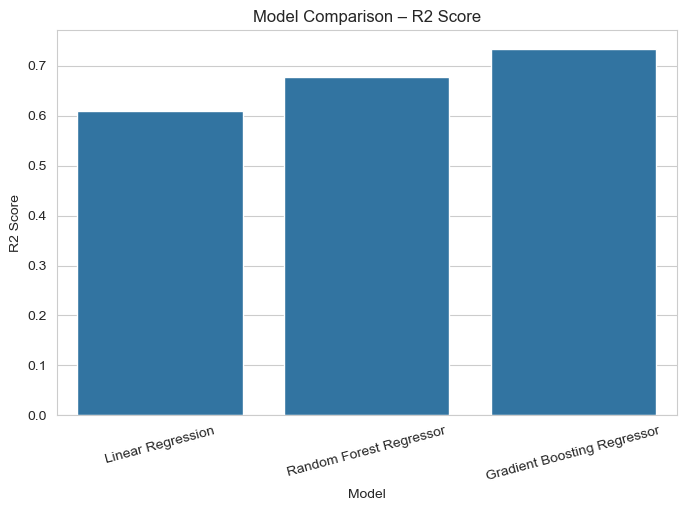

In [24]:
plt.figure(figsize=(8, 5))
sns.barplot(x="Model", y="R2 Score", data=results)
plt.title("Model Comparison – R2 Score")
plt.ylabel("R2 Score")
plt.xticks(rotation=15)
plt.show()

## 14. Selection of the Best Performing Model

The three regression models are compared using MAE, RMSE, and R².

For MAE and RMSE, lower values indicate better performance.

For R², a higher value indicates better performance.

The Gradient Boosting Regressor is selected as the final model because
it provides the best overall performance among the tested models.

In [25]:
# Select the model with the highest R2 score
best_model_row = results.loc[results["R2 Score"].idxmax()]

best_model_name = best_model_row["Model"]
best_mae = best_model_row["MAE"]
best_rmse = best_model_row["RMSE"]
best_r2 = best_model_row["R2 Score"]

print("Best Performing Model:", best_model_name)
print("MAE :", best_mae)
print("RMSE:", best_rmse)
print("R2  :", best_r2)

Best Performing Model: Gradient Boosting Regressor
MAE : 115261.92864870427
RMSE: 179366.11955529152
R2  : 0.7342761586842921


## 15. Feature Importance Analysis

Feature importance helps us understand which input features contribute
most to the predictions made by the Gradient Boosting model.

A higher importance value means that the feature contributed more to
the model's decision-making process.

In [26]:
# Get the fitted preprocessor from the Gradient Boosting pipeline
gb_preprocessor = gradient_boosting_model.named_steps["preprocessor"]

# Get the encoded categorical feature names
encoded_categorical_features = (
    gb_preprocessor
    .named_transformers_["categorical"]
    .get_feature_names_out(categorical_features)
)

# Combine categorical and numerical feature names
all_feature_names = np.concatenate([
    encoded_categorical_features,
    numeric_features
])

# Get feature importance from Gradient Boosting
gb_importances = (
    gradient_boosting_model
    .named_steps["model"]
    .feature_importances_
)

# Create a DataFrame
feature_importance_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": gb_importances
})

# Sort from highest to lowest importance
feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

# Display top 15 features
feature_importance_df.head(15)

,Feature,Importance
42,car_age,0.579345
29,fuel_Diesel,0.105945
35,transmission_Automatic,0.056364
24,brand_Tata,0.036631
25,brand_Toyota,0.032853
43,km_driven,0.028818
36,transmission_Manual,0.023893
44,km_per_year,0.020034
16,brand_Maruti,0.013095
3,brand_Chevrolet,0.011874


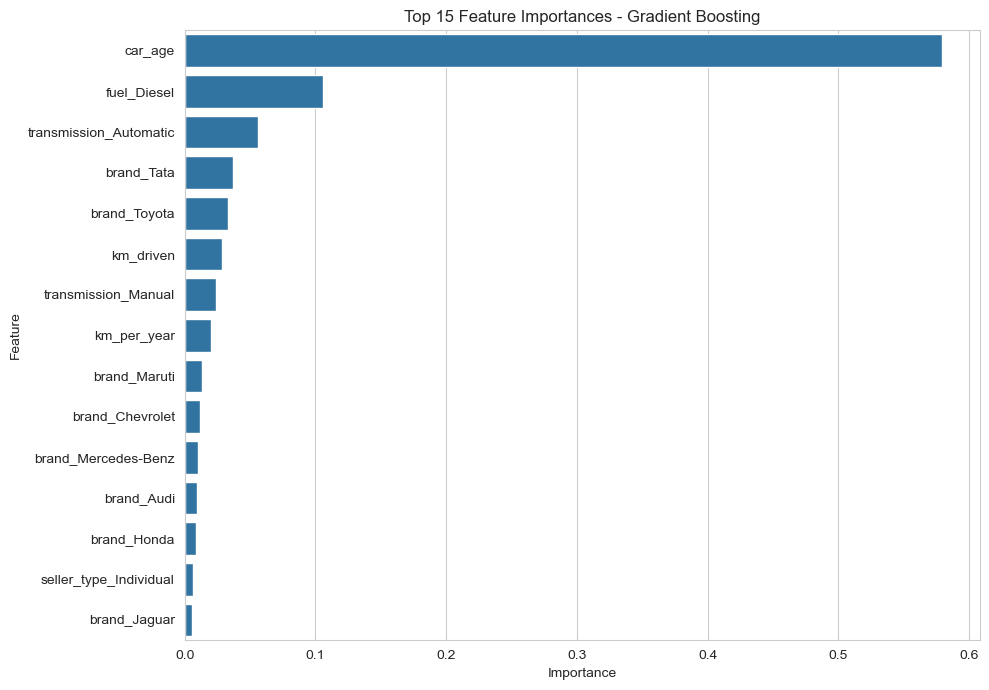

In [27]:
# Select top 15 features
top_features = feature_importance_df.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    x="Importance",
    y="Feature",
    data=top_features
)

plt.title("Top 15 Feature Importances - Gradient Boosting")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

### Observation

The feature importance chart shows which features contributed most
to the Gradient Boosting model's predictions.

Features with higher importance had a greater influence on the
predicted selling prices.

The chart helps identify the most useful factors for predicting
the resale value of used cars.

## 16. Actual vs Predicted Selling Price

This graph compares the actual selling prices of cars with the prices
predicted by the Gradient Boosting model.

If the predicted prices are close to the actual prices, the model is
performing well.

The diagonal reference line represents perfect prediction. Points
closer to this line indicate more accurate predictions.


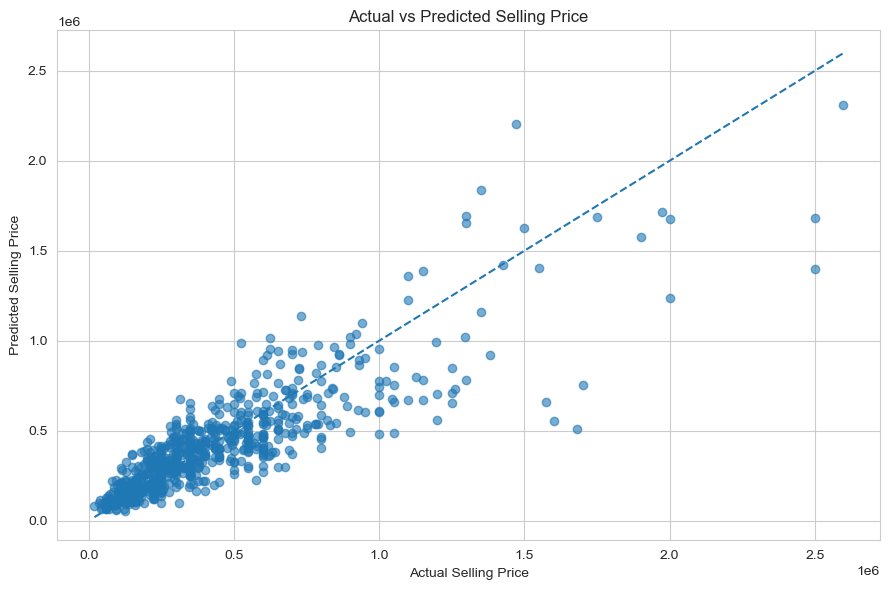

In [28]:
# Actual vs Predicted Selling Price

plt.figure(figsize=(9, 6))

plt.scatter(
    y_test_actual,
    gb_predictions,
    alpha=0.6
)

# Perfect prediction line
min_price = min(y_test_actual.min(), gb_predictions.min())
max_price = max(y_test_actual.max(), gb_predictions.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle="--"
)

plt.title("Actual vs Predicted Selling Price")
plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")

plt.tight_layout()
plt.show()

### Observation

The graph compares the actual selling prices with the prices predicted
by the Gradient Boosting model.

Most points are reasonably close to the diagonal line, which indicates
that the model is able to predict many car prices reasonably well.

Some points are farther away from the line, showing that the model
has larger prediction errors for certain cars.

Overall, the graph supports the model evaluation results, where the
Gradient Boosting Regressor achieved an R² score of approximately
0.734.

## 17. Final Model Performance

The Gradient Boosting Regressor achieved the best performance among
the three tested regression models.

Its performance was evaluated using Mean Absolute Error (MAE),
Root Mean Squared Error (RMSE), and R² score.

In [29]:
print("FINAL MODEL PERFORMANCE")
print("=======================")

print("Model :", best_model_name)
print("MAE   : ₹", round(best_mae, 2))
print("RMSE  : ₹", round(best_rmse, 2))
print("R²    :", round(best_r2, 4))

FINAL MODEL PERFORMANCE
Model : Gradient Boosting Regressor
MAE   : ₹ 115261.93
RMSE  : ₹ 179366.12
R²    : 0.7343


# 18. Conclusion

In this project, machine learning techniques were used to predict
the selling prices of used cars using the CarDekho dataset.

The dataset was first examined and cleaned by checking for missing
values, duplicate records, and categorical values. Feature engineering
was then performed by creating car age and kilometres driven per year.

Exploratory Data Analysis was carried out using a selling-price
distribution plot, fuel-type box plot, scatter plots, and a
correlation heatmap. These visualisations helped identify patterns
and relationships between the features and selling price.

Categorical features were converted into numerical features using
One-Hot Encoding. The dataset was divided into training and testing
sets using an 80:20 split.

Three regression models were trained and compared:

1. Linear Regression
2. Random Forest Regressor
3. Gradient Boosting Regressor

The models were evaluated using Mean Absolute Error (MAE),
Root Mean Squared Error (RMSE), and R² score.

Among the tested models, the Gradient Boosting Regressor achieved
the best overall performance, with the highest R² score and the
lowest prediction errors.

Feature importance analysis was also performed to identify the
features that contributed most to the model's predictions.

Overall, this project demonstrates how data cleaning, feature
engineering, exploratory data analysis, categorical encoding, and
machine learning can be used together to estimate the resale price
of used cars.